In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. tensorflow v2.xx에서 v1사용하기

In [4]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()  # v2를 비활성화하고 v1활성화
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프(tensor객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [5]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [6]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [7]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [8]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1., 2., 3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [9]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([2]) # 평균0, 표준편차가 1인 난수 실수 2개(정규분포이루는난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a,b])

[array([-1.0459741 , -0.19332533], dtype=float32),
 array([-0.5225177], dtype=float32)]

In [10]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([0.4109144], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [11]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight오 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# Hypothesis : 예측값
H = W*x + b
#cost function(손실함수 = mse;최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientDescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드에 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 == 0:
        print("{}번째 cost:{}, W:{}, b:{}".format(step,
                                               cost_val,
                                               W_val,
                                               b_val))

0번째 cost:0.6102613806724548, W:[1.1024914], b:[1.4874262]
200번째 cost:0.007560661528259516, W:[0.89925337], b:[1.2290207]
400번째 cost:0.002887032926082611, W:[0.9377447], b:[1.141521]
600번째 cost:0.0011024156119674444, W:[0.9615299], b:[1.0874516]
800번째 cost:0.0004209510807413608, W:[0.9762279], b:[1.0540396]
1000번째 cost:0.00016074252198450267, W:[0.9853102], b:[1.0333934]
1200번째 cost:6.138154276413843e-05, W:[0.9909225], b:[1.0206356]
1400번째 cost:2.3439055439666845e-05, W:[0.9943906], b:[1.0127515]
1600번째 cost:8.949081347964238e-06, W:[0.9965339], b:[1.0078793]
1800번째 cost:3.4167326248280006e-06, W:[0.99785835], b:[1.0048685]
2000번째 cost:1.304804300161777e-06, W:[0.99867654], b:[1.0030085]
2200번째 cost:4.983008352610341e-07, W:[0.99918205], b:[1.0018592]
2400번째 cost:1.9039102028273192e-07, W:[0.9994944], b:[1.0011494]
2600번째 cost:7.292634052191715e-08, W:[0.9996872], b:[1.0007112]
2800번째 cost:2.797979448132537e-08, W:[0.9998062], b:[1.0004407]
3000번째 cost:1.0788720139487395e-08, W:[0.9998

In [12]:
# 최종적으로 나온 회귀식 : H = W*x + b
sess.run([W, b])

[array([0.9999891], dtype=float32), array([1.0000248], dtype=float32)]

In [13]:
W_, b_ = sess.run([W, b])
W_[0], b_[0]

(0.9999891, 1.0000248)

In [14]:
def predict(x):
    return W_[0]*x + b_[0]

In [15]:
input_x = int(input('입력값은 ?'))
print('예측값은 ', predict(input_x))

입력값은 ?3
예측값은  3.999992072582245


## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [16]:
# x = np.array([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [17]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                   y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:0.4611523151397705, W:[1.9953592], b:[0.59000516]
200째 : cost:0.004651524126529694, W:[2.0231938], b:[0.87602866]
400째 : cost:0.00045752269215881824, W:[2.0072742], b:[0.96111983]
600째 : cost:4.500328213907778e-05, W:[2.0022812], b:[0.9878062]
800째 : cost:4.426904524734709e-06, W:[2.0007155], b:[0.9961754]
1000째 : cost:4.353304632331856e-07, W:[2.0002246], b:[0.9988004]
1200째 : cost:4.279860377209843e-08, W:[2.0000703], b:[0.9996236]
1400째 : cost:4.222568072975719e-09, W:[2.000022], b:[0.999882]
1600째 : cost:4.2150533063889384e-10, W:[2.0000072], b:[0.99996245]
1800째 : cost:5.917399903410114e-11, W:[2.0000026], b:[0.9999863]
2000째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2200째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2400째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2600째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2800째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
3000째 : cost:2.060005464821

In [18]:
# 예측하기
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [19]:
sess.run(H, feed_dict={x:np.array([5, 6, 7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

## 2.3 scale이 다른 데이터의 linear regression 구현(scale조정X)

In [20]:
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 3000번 학습
for step in range(3001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                   y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:4512.87109375, W:[7.6476073], b:[1.6806307]
200째 : cost:83.79859924316406, W:[10.165588], b:[-0.3587843]
400째 : cost:83.51134490966797, W:[10.261185], b:[-1.0666034]
600째 : cost:83.4849624633789, W:[10.29014], b:[-1.2809963]
800째 : cost:83.48255157470703, W:[10.29891], b:[-1.3459343]
1000째 : cost:83.48231506347656, W:[10.301567], b:[-1.365604]
1200째 : cost:83.48233795166016, W:[10.302371], b:[-1.3715615]
1400째 : cost:83.48231506347656, W:[10.302615], b:[-1.373365]
1600째 : cost:83.48231506347656, W:[10.302689], b:[-1.3739115]
1800째 : cost:83.48231506347656, W:[10.3027115], b:[-1.3740755]
2000째 : cost:83.48230743408203, W:[10.302717], b:[-1.3741244]
2200째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2400째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2600째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2800째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
3000째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]


In [21]:
# cost값이 멈춤 : local 최소값

## 2.4 scale이 다른 데이터의 linear regression을 구현(조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization(정규화) : 0~1로 조정 X - Xmin normalization = ──────────── Xmax - Xmin * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler이용)

- standardization(표준화) : 평균0, 표준편차1로 조정 X - Xmean(평균) standardization = ────────────────── Xstd(표준편차) * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler이용)

In [22]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min() ) / (x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min() ) / (y_data.max() - y_data.min())
print(scaled_x_data)
print(scaled_y_data)

[0.         0.11111111 0.44444444 0.77777778 1.        ]
[0.         0.13043478 0.70652174 0.83695652 1.        ]


In [23]:
# 라이브러리를 쓰고 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [24]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                   y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:0.3103836178779602, W:[0.07142001], b:[0.08663546]
600째 : cost:0.08273297548294067, W:[0.31960067], b:[0.32231802]
1200째 : cost:0.05723945423960686, W:[0.43757388], b:[0.34203523]
1800째 : cost:0.04529841989278793, W:[0.518277], b:[0.31775528]
2400째 : cost:0.03663671016693115, W:[0.58355767], b:[0.28737816]
3000째 : cost:0.03010585904121399, W:[0.63922775], b:[0.25889146]
3600째 : cost:0.025168761610984802, W:[0.68739057], b:[0.23365761]
4200째 : cost:0.021435825154185295, W:[0.7292157], b:[0.21161208]
4800째 : cost:0.01861334592103958, W:[0.7655719], b:[0.1924194]
5400째 : cost:0.016479238867759705, W:[0.79718286], b:[0.17572531]
6000째 : cost:0.014865626581013203, W:[0.8246692], b:[0.16120784]
6600째 : cost:0.013645565137267113, W:[0.84856975], b:[0.14858396]
7200째 : cost:0.012723070569336414, W:[0.8693523], b:[0.13760696]
7800째 : cost:0.012025576084852219, W:[0.8874233], b:[0.12806201]
8400째 : cost:0.011498193256556988, W:[0.9031369], b:[0.11976225]
9000째 : cost:0.0110994335263967

In [25]:
# 예측 : 모델에 scale 조정된 값으로 예측=>scale 조정된 y값
scaled_input = scaler_x.transform(np.array([[2],
                                            [3]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :', scaled_output, sep='\n')
print('결과 :', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.19531   ]
 [0.30226558]]
결과 :
[[20.968521]
 [30.808434]]


In [26]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

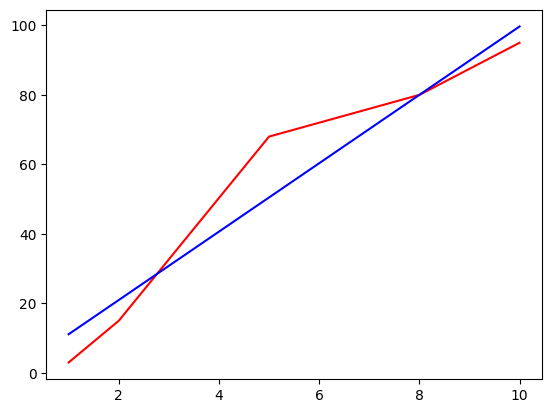

In [27]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [28]:
# 라이브러리를 쓰고 표준화 (StandardScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)

from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [29]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                   y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:1.05403733253479, W:[0.1139628], b:[0.5076952]
600째 : cost:0.15240314602851868, W:[0.7111828], b:[0.1527312]
1200째 : cost:0.07080519944429398, W:[0.8908456], b:[0.04594649]
1800째 : cost:0.06342050433158875, W:[0.9448944], b:[0.01382221]
2400째 : cost:0.06275219470262527, W:[0.9611538], b:[0.00415818]
3000째 : cost:0.06269172579050064, W:[0.9660451], b:[0.00125092]
3600째 : cost:0.06268622726202011, W:[0.9675167], b:[0.00037633]
4200째 : cost:0.0626857653260231, W:[0.9679594], b:[0.00011322]
4800째 : cost:0.06268569082021713, W:[0.9680915], b:[3.40695e-05]
5400째 : cost:0.06268569082021713, W:[0.96813416], b:[1.0258225e-05]
6000째 : cost:0.06268569082021713, W:[0.96813506], b:[3.1045467e-06]
6600째 : cost:0.06268569827079773, W:[0.96813506], b:[9.5309e-07]
7200째 : cost:0.06268569827079773, W:[0.96813506], b:[3.046666e-07]
7800째 : cost:0.06268569082021713, W:[0.96813506], b:[1.1351395e-07]
8400째 : cost:0.06268568336963654, W:[0.96813506], b:[5.624893e-08]
9000째 : cost:0.062685683369636

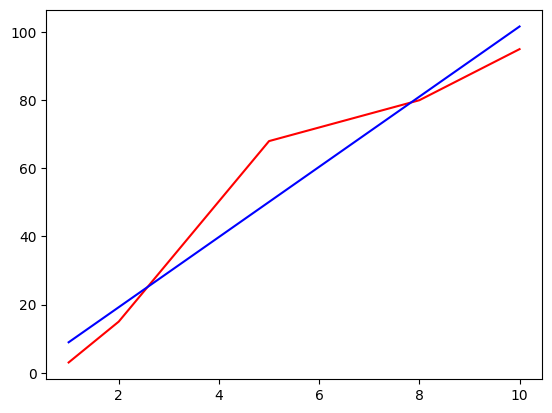

In [30]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')